# Generate PEMMDB Profiles — `my_pemmdb_profiles_2030.nc`

This notebook generates `data/open-tyndp/my_pemmdb_profiles_2030.nc` from PEMMDB2 Excel files
provided by ENTSO-E as part of the TYNDP 2024 dataset, and then analyses the structure
and content of the resulting dataset.

**Inputs:**
- `data/tyndp2024/PEMMDB2/2030/*.xlsx` — PEMMDB2 Excel files (one per node)
- `data/open-tyndp/tyndp_technology_map.csv` — technology → open-tyndp carrier mapping
- `data/open-tyndp/buses.csv` — network node list

**Outputs:**
- `data/open-tyndp/my_pemmdb_profiles_2030.nc` — hourly `p_min_pu` and `p_max_pu` profiles (CY2009, 8760 h)
- `data/open-tyndp/my_pemmdb_capacities_2030.csv` — installed capacities (MW / MWh) per node and carrier


## 1. Configuration


In [19]:
import sys
import logging
import types
import importlib.util
from pathlib import Path
from functools import partial
from itertools import product

import numpy as np
import pandas as pd
import xarray as xr
from tqdm.notebook import tqdm

# Paths
BASE_DIR        = Path("..").resolve()
PEMMDB_DIR      = BASE_DIR / "data/tyndp2024/PEMMDB2"   # script appends /{pyear}/ internally
CARRIER_MAP_CSV = BASE_DIR / "data/open-tyndp/tyndp_technology_map.csv"
OUT_PROFILES    = BASE_DIR / "data/open-tyndp/my_pemmdb_profiles_2030.nc"
OUT_CAPACITIES  = BASE_DIR / "data/open-tyndp/my_pemmdb_capacities_2030.csv"

# Parameters
CYEAR          = 2009    # climate year (CY2009 used throughout TYNDP 2024)
PYEAR          = 2030    # planning year
PYEAR_I        = 2030
TYNDP_SCENARIO = "NT"   # National Trends scenario

# Technologies to process (mirrors open-tyndp NT config)
PEMMDB_TECHS = [
    "Nuclear", "Hard coal", "Lignite", "Gas", "Light oil", "Heavy oil", "Oil shale",
    "Hydrogen", "Other Non-RES", "DSR", "Other RES", "Battery", "Hydro",
]

print(f"BASE_DIR    : {BASE_DIR}")
print(f"PEMMDB_DIR  : {PEMMDB_DIR}")
print(f"Out profiles: {OUT_PROFILES}")
print(f"Out caps    : {OUT_CAPACITIES}")


BASE_DIR    : /Users/radovanhodor/Documents/TUKE/Final diplomova praca
PEMMDB_DIR  : /Users/radovanhodor/Documents/TUKE/Final diplomova praca/data/tyndp2024/PEMMDB2
Out profiles: /Users/radovanhodor/Documents/TUKE/Final diplomova praca/data/open-tyndp/my_pemmdb_profiles_2030.nc
Out caps    : /Users/radovanhodor/Documents/TUKE/Final diplomova praca/data/open-tyndp/my_pemmdb_capacities_2030.csv


## 2. Load `build_pemmdb_data.py` helper module

The open-tyndp script `build_pemmdb_data.py` uses `from scripts._helpers import ...`.
We shim that import so the module loads without the full Snakemake project structure.


In [20]:
logging.basicConfig(level=logging.WARNING, format="%(levelname)s - %(message)s")

GRID_MODEL_DIR = BASE_DIR / "grid-model"
if str(GRID_MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(GRID_MODEL_DIR))

# --- Mock scripts._helpers ---
# build_pemmdb_data.py imports only these 6 symbols from scripts._helpers.
# We define them directly here to avoid loading the full _helpers.py
# (which requires atlite, fiona, git, pypsa, etc.).

from bisect import bisect_right

def configure_logging(snakemake, skip_handlers=False):
    logging.basicConfig(level=logging.WARNING)

def set_scenario_config(snakemake):
    pass

def get_snapshots(snapshots, drop_leap_day=False, freq="h", **kwargs):
    start = snapshots["start"] if isinstance(snapshots["start"], list) else [snapshots["start"]]
    end   = snapshots["end"]   if isinstance(snapshots["end"],   list) else [snapshots["end"]]
    time  = pd.DatetimeIndex([])
    for s, e in zip(start, end):
        period = pd.date_range(start=s, end=e, freq=freq, inclusive=snapshots["inclusive"], **kwargs)
        time = time.append(period)
    if drop_leap_day and time.is_leap_year.any():
        time = time[~((time.month == 2) & (time.day == 29))]
    return time

def safe_pyear(year, available_years=[2030, 2040, 2050], source="TYNDP", verbose=True):
    if not isinstance(year, int):
        year = int(year)
    if year not in available_years:
        year_new = available_years[bisect_right(sorted(available_years), year, lo=1) - 1]
        if verbose:
            logging.warning(f"{source} data unavailable for {year}. Falling back to {year_new}.")
        return year_new
    return year

def map_tyndp_carrier_names(df, carrier_mapping_fn, on_columns, drop_on_columns=False):
    carrier_mapping = (
        pd.read_csv(carrier_mapping_fn)[on_columns + ["open_tyndp_carrier", "open_tyndp_index", "open_tyndp_type"]]
    ).dropna()
    df = df.merge(carrier_mapping, on=on_columns, how="left")
    if "pemmdb_carrier" in on_columns:
        def normalize_carrier(s):
            return s.lower().replace(" ", "-").replace("other-non-res", "chp")
        df = df.assign(
            open_tyndp_carrier=lambda x: np.where(
                x["pemmdb_carrier"].isin(["DSR", "Other Non-RES"]),
                x["pemmdb_carrier"].apply(normalize_carrier),
                x["open_tyndp_carrier"],
            ),
            open_tyndp_index=lambda x: np.where(
                x["pemmdb_carrier"].isin(["DSR", "Other Non-RES"]),
                x["open_tyndp_carrier"] + "-" + x["pemmdb_type"].apply(normalize_carrier),
                x["open_tyndp_index"],
            ),
        )
    if not drop_on_columns:
        return df
    df = df.drop(on_columns, axis="columns").rename(
        columns={"open_tyndp_carrier": "carrier", "open_tyndp_index": "index_carrier"}
    )
    cols = ["carrier", "index_carrier"] + [c for c in df.columns if c not in ["carrier", "index_carrier"]]
    return df[cols]

def convert_units(df, unit_col="unit", value_col="value", invert=False):
    return df

def mock_snakemake(*args, **kwargs):
    raise NotImplementedError("mock_snakemake not needed in notebook mode")

# Register as scripts._helpers
scripts_pkg = types.ModuleType("scripts")
scripts_pkg.__path__ = [str(GRID_MODEL_DIR)]
scripts_pkg.__package__ = "scripts"
sys.modules["scripts"] = scripts_pkg

helpers_mod = types.ModuleType("scripts._helpers")
helpers_mod.configure_logging    = configure_logging
helpers_mod.set_scenario_config  = set_scenario_config
helpers_mod.get_snapshots        = get_snapshots
helpers_mod.safe_pyear           = safe_pyear
helpers_mod.map_tyndp_carrier_names = map_tyndp_carrier_names
helpers_mod.convert_units        = convert_units
helpers_mod.mock_snakemake       = mock_snakemake
sys.modules["scripts._helpers"]  = helpers_mod

# Load build_pemmdb_data
spec2 = importlib.util.spec_from_file_location(
    "build_pemmdb_data",
    GRID_MODEL_DIR / "build_pemmdb_data.py",
)
bpd = importlib.util.module_from_spec(spec2)
bpd.__name__ = "build_pemmdb_data"
spec2.loader.exec_module(bpd)

print("build_pemmdb_data loaded successfully")
print(f"PEMMDB_SHEET_MAPPING keys: {list(bpd.PEMMDB_SHEET_MAPPING.keys())}")


build_pemmdb_data loaded successfully
PEMMDB_SHEET_MAPPING keys: ['Gas', 'Nuclear', 'Hard coal', 'Lignite', 'Light oil', 'Heavy oil', 'Oil shale', 'Hydrogen']


## 3. Discover nodes and prepare snapshots


In [21]:
# Hourly snapshots for climate year
sns = pd.date_range(start=f"{CYEAR}-01-01", end=f"{CYEAR+1}-01-01", freq="h", inclusive="left")
sns_year_h = sns
print(f"Snapshots: {len(sns)} hours  ({sns[0]} → {sns[-1]})")

# Discover nodes from available PEMMDB Excel files
pemmdb_year_dir = PEMMDB_DIR / str(PYEAR)
pemmdb_files = sorted(pemmdb_year_dir.glob("PEMMDB_*_NationalTrends_2030.xlsx"))
nodes = pd.Index([f.stem.split("_")[1] for f in pemmdb_files])
print(f"\nFound {len(nodes)} nodes in {pemmdb_year_dir}:")
print(list(nodes))

# Determine which technology sheets to process
pemmdb_tech_sheets = list({bpd.PEMMDB_SHEET_MAPPING.get(t, t) for t in PEMMDB_TECHS})
thermal_techs = [k for k, v in bpd.PEMMDB_SHEET_MAPPING.items() if v == "Thermal"]
print(f"\nTechnology sheets to process: {pemmdb_tech_sheets}")


Snapshots: 8760 hours  (2009-01-01 00:00:00 → 2009-12-31 23:00:00)

Found 77 nodes in /Users/radovanhodor/Documents/TUKE/Final diplomova praca/data/tyndp2024/PEMMDB2/2030:
['AL00', 'AT00', 'BA00', 'BE00', 'BEOF', 'BG00', 'CH00', 'CY00', 'CZ00', 'DE00', 'DEKF', 'DKBH', 'DKE1', 'DKKF', 'DKNS', 'DKW1', 'DZ00', 'EE00', 'EEOF', 'EG00', 'ES00', 'FI00', 'FR00', 'FR15', 'GE00', 'GR00', 'GR03', 'HR00', 'HU00', 'IE00', 'IL00', 'ITA00', 'ITCA', 'ITCN', 'ITCS', 'ITN1', 'ITS1', 'ITSA', 'ITSI', 'LT00', 'LTOF', 'LUB1', 'LUF1', 'LUG1', 'LUV1', 'LV00', 'LY00', 'MA00', 'MD00', 'ME00', 'MK00', 'MT00', 'NL00', 'NL60', 'NL6H', 'NLA0', 'NLBH', 'NLLL', 'NOM1', 'NON1', 'NOS0', 'PL00', 'PS00', 'PT00', 'RO00', 'RS00', 'SE01', 'SE02', 'SE03', 'SE04', 'SI00', 'SK00', 'TN00', 'TR00', 'UA00', 'UK00', 'UKNI']

Technology sheets to process: ['Thermal', 'Battery', 'Other Non-RES', 'DSR', 'Hydro', 'Other RES']


## 4. Load PEMMDB Excel files


In [22]:
func_read = partial(
    bpd.read_pemmdb_data,
    pemmdb_dir=str(PEMMDB_DIR),
    cyear=CYEAR,
    pyear=PYEAR,
    required_sheets=pemmdb_tech_sheets,
)

pemmdb_data = {}
for node in tqdm(nodes, desc="Loading PEMMDB Excel files"):
    result = func_read(node)
    if result is not None:
        pemmdb_data.update(result)

print(f"\nLoaded data for {len(pemmdb_data)} nodes")


Loading PEMMDB Excel files:   0%|          | 0/77 [00:00<?, ?it/s]


Loaded data for 77 nodes


## 5. Process capacities and profiles

For each `(node, technology sheet)` combination, call `process_pemmdb_data` twice:
once for `"capacities"` and once for `"profiles"`.
Nodes/sheets that fail (e.g. missing Battery tabs for non-EU nodes) are skipped with a warning.


In [23]:
node_tech_sheets = list(product(nodes, pemmdb_tech_sheets))
print(f"Total (node, sheet) combinations: {len(node_tech_sheets)}")

process_kwargs = dict(
    pemmdb_data=pemmdb_data,
    thermal_techs=thermal_techs,
    cyear=CYEAR,
    pyear=PYEAR,
    pyear_i=PYEAR_I,
    tyndp_scenario=TYNDP_SCENARIO,
    sns=sns,
    sns_year_h=sns_year_h,
    carrier_mapping_fn=str(CARRIER_MAP_CSV),
)

# Capacities
pemmdb_capacities = []
skipped_caps = []
for nts in tqdm(node_tech_sheets, desc="Processing capacities"):
    try:
        result = bpd.process_pemmdb_data("capacities", node_tech_sheet=nts, **process_kwargs)
        if result is not None:
            pemmdb_capacities.append(result)
    except Exception as e:
        skipped_caps.append((nts, str(e)))

pemmdb_capacities_df = pd.concat(pemmdb_capacities, axis=0) if pemmdb_capacities else pd.DataFrame()
print(f"\nCapacities: {len(pemmdb_capacities_df)} rows  |  skipped: {len(skipped_caps)} combinations")

# Profiles
pemmdb_profiles = []
skipped_profs = []
for nts in tqdm(node_tech_sheets, desc="Processing profiles"):
    try:
        result = bpd.process_pemmdb_data("profiles", node_tech_sheet=nts, **process_kwargs)
        if result is not None:
            pemmdb_profiles.append(result)
    except Exception as e:
        skipped_profs.append((nts, str(e)))

pemmdb_profiles_df = pd.concat(pemmdb_profiles, axis=0) if pemmdb_profiles else pd.DataFrame()
print(f"Profiles  : {len(pemmdb_profiles_df)} rows  |  skipped: {len(skipped_profs)} combinations")


Total (node, sheet) combinations: 462


Processing capacities:   0%|          | 0/462 [00:00<?, ?it/s]


Capacities: 3215 rows  |  skipped: 9 combinations


Processing profiles:   0%|          | 0/462 [00:00<?, ?it/s]

Profiles  : 1638120 rows  |  skipped: 0 combinations


## 6. Save outputs to disk


In [24]:
# Save capacities CSV
if not pemmdb_capacities_df.empty:
    pemmdb_capacities_df.to_csv(OUT_CAPACITIES, index=False)
    print(f"Saved capacities: {OUT_CAPACITIES}  ({len(pemmdb_capacities_df)} rows)")
else:
    print("WARNING: no capacity data to save")

# Build xarray Dataset and save NetCDF
if pemmdb_profiles_df.empty:
    print("WARNING: no profile data to save")
else:
    ds = xr.Dataset(
        {
            "p_min_pu": (["sample"], pemmdb_profiles_df["p_min_pu"].values),
            "p_max_pu": (["sample"], pemmdb_profiles_df["p_max_pu"].values),
        },
        coords={
            level: (["sample"], pemmdb_profiles_df.index.get_level_values(level))
            for level in pemmdb_profiles_df.index.names
        },
    )
    ds.to_netcdf(OUT_PROFILES)
    print(f"Saved profiles : {OUT_PROFILES}")
    print(f"  Size on disk : {OUT_PROFILES.stat().st_size / 1e6:.1f} MB")


Saved capacities: /Users/radovanhodor/Documents/TUKE/Final diplomova praca/data/open-tyndp/my_pemmdb_capacities_2030.csv  (3215 rows)


Saved profiles : /Users/radovanhodor/Documents/TUKE/Final diplomova praca/data/open-tyndp/my_pemmdb_profiles_2030.nc
  Size on disk : 431.8 MB


## 7. Dataset Analysis — Structure and Features

Reload the saved NetCDF and inspect its dimensions, coordinates, variables, carriers and time coverage.


In [25]:
# Reload saved dataset and print overview
ds = xr.open_dataset(OUT_PROFILES)
print("=== xarray Dataset overview ===")
print(ds)


=== xarray Dataset overview ===
<xarray.Dataset> Size: 531MB
Dimensions:          (sample: 1638120)
Coordinates:
    time             (sample) datetime64[ns] 13MB ...
    bus              (sample) <U4 26MB ...
    carrier          (sample) <U9 59MB ...
    index_carrier    (sample) <U53 347MB ...
    open_tyndp_type  (sample) <U9 59MB ...
Dimensions without coordinates: sample
Data variables:
    p_min_pu         (sample) float64 13MB ...
    p_max_pu         (sample) float64 13MB ...


In [26]:
df = ds.to_dataframe().reset_index()

print("=== DataFrame shape and columns ===")
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print()
print("=== Data types ===")
print(df.dtypes)
print()
print("=== First 5 rows ===")
df.head()


=== DataFrame shape and columns ===
Shape  : (1638120, 8)
Columns: ['sample', 'p_min_pu', 'p_max_pu', 'time', 'bus', 'carrier', 'index_carrier', 'open_tyndp_type']

=== Data types ===
sample                      int64
p_min_pu                  float64
p_max_pu                  float64
time               datetime64[ns]
bus                        object
carrier                    object
index_carrier              object
open_tyndp_type            object
dtype: object

=== First 5 rows ===


,sample,p_min_pu,p_max_pu,time,bus,carrier,index_carrier,open_tyndp_type
0,0,0.0,0.549245,2009-01-01 00:00:00,AT00,chp,chp-gas-ccgt-old-1-other-70.65eur,
1,1,0.0,0.549245,2009-01-01 01:00:00,AT00,chp,chp-gas-ccgt-old-1-other-70.65eur,
2,2,0.0,0.549245,2009-01-01 02:00:00,AT00,chp,chp-gas-ccgt-old-1-other-70.65eur,
3,3,0.0,0.549245,2009-01-01 03:00:00,AT00,chp,chp-gas-ccgt-old-1-other-70.65eur,
4,4,0.0,0.549245,2009-01-01 04:00:00,AT00,chp,chp-gas-ccgt-old-1-other-70.65eur,


In [27]:
print("=== Unique values per coordinate ===")
print(f"time            : {df.time.nunique()} unique hours  ({df.time.min()} → {df.time.max()})")
print(f"bus             : {df.bus.nunique()} unique nodes")
print(f"carrier         : {sorted(df.carrier.unique())}")
print(f"open_tyndp_type : {sorted(df.open_tyndp_type.unique())}")
print(f"index_carrier   : {df.index_carrier.nunique()} unique sub-types")


=== Unique values per coordinate ===
time            : 8760 unique hours  (2009-01-01 00:00:00 → 2009-12-31 23:00:00)
bus             : 50 unique nodes
carrier         : ['chp', 'coal', 'dsr', 'gas', 'h2-ccgt', 'lignite', 'oil-heavy', 'oil-light', 'other-res', 'uranium']
open_tyndp_type : ['', 'coal', 'gas-ccgt', 'gas-conv', 'gas-ocgt', 'h2-ccgt', 'lignite', 'nuclear', 'oil-heavy', 'oil-light', 'other-res']
open_tyndp_type : ['', 'coal', 'gas-ccgt', 'gas-conv', 'gas-ocgt', 'h2-ccgt', 'lignite', 'nuclear', 'oil-heavy', 'oil-light', 'other-res']
index_carrier   : 59 unique sub-types
index_carrier   : 59 unique sub-types


In [38]:
print(df.index_carrier.nunique())
print(df.index_carrier.unique())


59
['chp-gas-ccgt-old-1-other-70.65eur' 'other-res' 'gas-ccgt-present2'
 'gas-conv-old2' 'coal-old2' 'chp-gas-conventional-old-2-industrial-0eur'
 'dsr-4h-1500eur' 'gas-conv-old1' 'nuclear'
 'chp-gas-conventional-old-1-industrial-0eur'
 'chp-gas-conventional-old-1-other-0eur' 'chp-lignite-old-1-other-0eur'
 'gas-ccgt-new' 'gas-ccgt-old2' 'gas-ccgt-present1' 'gas-ocgt-new'
 'h2-ccgt' 'oil-light' 'chp-gas-conventional-old-1-other-128.4eur'
 'dsr-24h-43.6eur' 'dsr-24h-87.1eur' 'gas-ccgt-old1' 'gas-ocgt-old'
 'coal-new' 'coal-old1' 'oil-heavy-old1' 'dsr-24h-1000eur'
 'chp-gas-ccgt-old-2-other-58.87500000000006eur'
 'chp-gas-ccgt-old-1-other-0eur' 'chp-gas-conventional-old-2-other-0eur'
 'dsr-12h-50eur' 'dsr-24h-75eur' 'dsr-2h-100eur' 'dsr-4h-150eur'
 'chp-gas-ocgt-old-other-0eur'
 'chp-gas-ocgt-old-other-82.34285714285716eur' 'dsr-10h-350eur'
 'chp-gas-conventional-old-1-district-heatring-128.4eur' 'lignite-old1'
 'chp--nan-0eur' 'chp-light-oil---industrial-0eur'
 'chp-oil-shale-old-indust

In [39]:
print(df.carrier.nunique())
print(df.carrier.unique())

10
['chp' 'other-res' 'gas' 'coal' 'dsr' 'uranium' 'h2-ccgt' 'oil-light'
 'oil-heavy' 'lignite']


In [40]:
print(df.open_tyndp_type.nunique())
print(df.open_tyndp_type.unique())

11
['' 'other-res' 'gas-ccgt' 'gas-conv' 'coal' 'nuclear' 'gas-ocgt'
 'h2-ccgt' 'oil-light' 'oil-heavy' 'lignite']


In [31]:
print("=== Per-carrier summary: row count, buses, p_min_pu and p_max_pu statistics ===")
print()
print(f"{'carrier':<14} {'open_tyndp_type':<20} {'rows':>8} {'buses':>6} "
      f"{'p_min mean':>10} {'p_min max':>10} {'p_max mean':>10} {'p_max<1 (%)':>12}")
print("-" * 100)

for (carrier, otype), grp in df.groupby(["carrier", "open_tyndp_type"]):
    rows     = len(grp)
    buses    = grp.bus.nunique()
    pm_mean  = grp.p_min_pu.mean()
    pm_max   = grp.p_min_pu.max()
    px_mean  = grp.p_max_pu.mean()
    px_lt1   = (grp.p_max_pu < 1.0).mean() * 100
    print(f"  {carrier:<14} {otype:<20} {rows:>8,} {buses:>6} "
          f"{pm_mean:>10.3f} {pm_max:>10.3f} {px_mean:>10.3f} {px_lt1:>11.1f}%")


=== Per-carrier summary: row count, buses, p_min_pu and p_max_pu statistics ===

carrier        open_tyndp_type          rows  buses p_min mean  p_min max p_max mean  p_max<1 (%)
----------------------------------------------------------------------------------------------------
  chp                                  367,920     27      0.000      0.000      0.432        98.1%
  coal           coal                  113,880      7      0.517      1.000      1.000         0.0%
  dsr                                   96,360      7      0.000      0.000      0.502        84.3%
  gas            gas-ccgt              332,880     23      0.232      0.963      1.000         0.0%
  gas            gas-conv               96,360     10      0.359      1.000      1.000         0.0%
  gas            gas-ocgt               87,600      6      0.438      0.961      1.000         0.0%
  h2-ccgt        h2-ccgt                 8,760      1      0.047      0.047      1.000         0.0%
  lignite        lig

### Key finding: `p_max_pu` for thermal carriers

For all dispatchable thermal carriers (`coal`, `gas`, `lignite`, `uranium`, `oil-*`, `h2-ccgt`)
**`p_max_pu` is always 1.0** — PEMMDB does not encode planned or forced outage availability.

The only carriers with meaningful `p_max_pu < 1` profiles are:
- **`chp`** — upper bound set by heat demand (cogeneración dispatch)
- **`dsr`** — demand side response availability window

For thermal availability (outages), a separate source is needed (e.g. Plexos output).
PEMMDB **does** provide useful **`p_min_pu`** (must-run obligations) for coal, gas, lignite, etc.


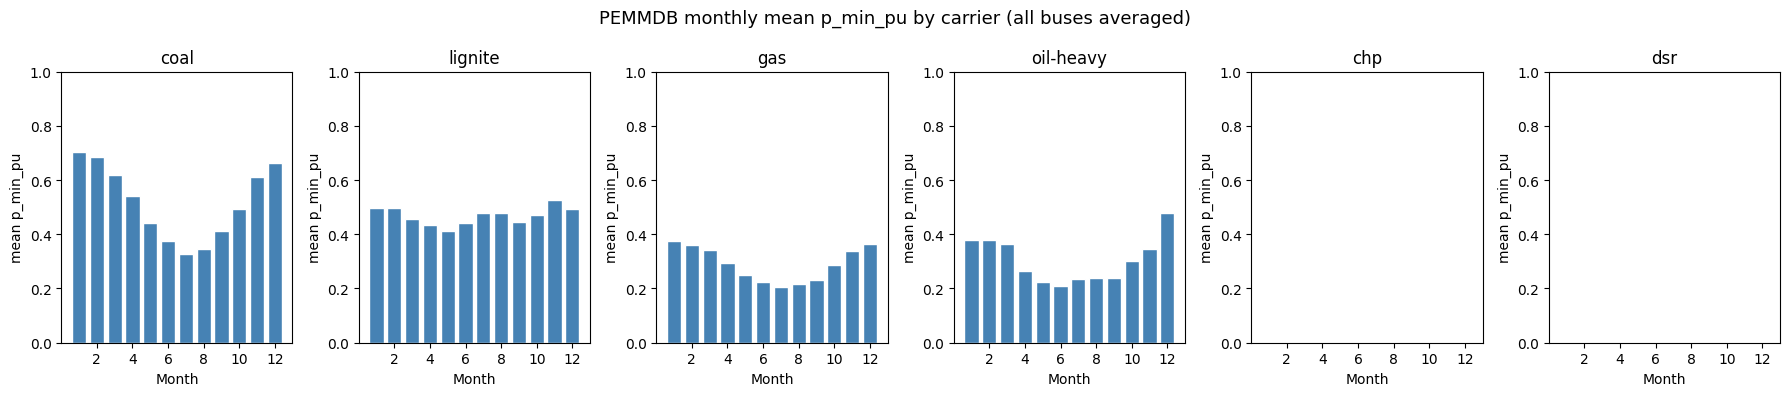

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Monthly mean p_min_pu for key thermal carriers (carriers with non-zero p_min_pu)
thermal_plot = ['coal', 'lignite', 'gas', 'oil-heavy', 'chp', 'dsr']

fig, axes = plt.subplots(1, len(thermal_plot), figsize=(18, 4), sharey=False)
fig.suptitle("PEMMDB monthly mean p_min_pu by carrier (all buses averaged)", fontsize=13)

for ax, carrier in zip(axes, thermal_plot):
    sub = df[df.carrier == carrier].copy()
    sub['month'] = sub.time.dt.month
    monthly = sub.groupby('month')['p_min_pu'].mean()
    ax.bar(monthly.index, monthly.values, color='steelblue', edgecolor='white')
    ax.set_title(carrier)
    ax.set_xlabel("Month")
    ax.set_ylabel("mean p_min_pu")
    ax.set_ylim(0, 1)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

plt.tight_layout()
plt.show()
